### Notebook to play with model ,then input funcotuon in machine learning version.py


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from image_processing import read_img,show_img
from machine_learning_version import extract_features,extract_label
from sklearn.metrics import root_mean_squared_error 
from simple_statistics import create_confusions_matrix
from image_processing import preproces_pipeline
import os
import numpy as np

INPUT_DIR:str="./images"
MANUAL_DIR:str="./manual1"
MASK_DIR:str="./mask"

KERNEL_SIZE:int=5
BOUNDARY:int=400

In [13]:
input_images=[INPUT_DIR+"/"+file.name for file in os.scandir(INPUT_DIR) if file.is_file()]
manual_images=[MANUAL_DIR+"/"+file.name for file in os.scandir(MANUAL_DIR) if file.is_file()]
mask_images=[MASK_DIR+"/"+file.name for file in os.scandir("./mask") if file.is_file()]

data=list(zip(input_images,manual_images,mask_images))
print(data)
print(len(data))

[('./images/01_dr.JPG', './manual1/01_dr.tif', './mask/01_dr_mask.tif'), ('./images/01_g.jpg', './manual1/01_g.tif', './mask/01_g_mask.tif'), ('./images/01_h.jpg', './manual1/01_h.tif', './mask/01_h_mask.tif'), ('./images/02_dr.JPG', './manual1/02_dr.tif', './mask/02_dr_mask.tif'), ('./images/02_g.jpg', './manual1/02_g.tif', './mask/02_g_mask.tif'), ('./images/02_h.jpg', './manual1/02_h.tif', './mask/02_h_mask.tif'), ('./images/03_dr.JPG', './manual1/03_dr.tif', './mask/03_dr_mask.tif'), ('./images/03_g.jpg', './manual1/03_g.tif', './mask/03_g_mask.tif'), ('./images/03_h.jpg', './manual1/03_h.tif', './mask/03_h_mask.tif'), ('./images/04_dr.JPG', './manual1/04_dr.tif', './mask/04_dr_mask.tif'), ('./images/04_g.jpg', './manual1/04_g.tif', './mask/04_g_mask.tif'), ('./images/04_h.jpg', './manual1/04_h.tif', './mask/04_h_mask.tif'), ('./images/05_dr.JPG', './manual1/05_dr.tif', './mask/05_dr_mask.tif'), ('./images/05_g.jpg', './manual1/05_g.tif', './mask/05_g_mask.tif'), ('./images/05_h.jp

In [14]:
all_features=[]
all_lebels=[]
for idx,element in enumerate(data):
    img=read_img(element[0])
    img=preproces_pipeline(img,11)
    manual_=read_img(element[1])
    mask_=read_img(element[2])

    manual_=manual_[:,:,1]
    manual_=np.where(manual_>0,1,0)
    max_x,max_y=img.shape
    center_x,center_y=max_x//2,max_y//2

    half = KERNEL_SIZE // 2
    
    for x in range(half,max_x-half):

        for y in range(half,max_y-half):
            if mask_[x,y,1]==0:#pomijanie tła
                continue
            patch = img[x-half:x+half+1,y-half:y+half+1]

            label_patch = manual_[x-half:x+half+1,y-half:y+half+1]

            features_sample = extract_features(patch)

            all_features.append(features_sample)

            all_lebels.append(
                extract_label(label_patch, KERNEL_SIZE)
            )
            if len(all_features)>(idx+1)*110_000:
                break


    #for x in range(KERNEL_SIZE//2+600,max_x-KERNEL_SIZE//2):
        #for y in range(KERNEL_SIZE//2+800,max_y-KERNEL_SIZE//2):

In [15]:
print(len([x for x in all_lebels if x==0]))
print(len([x for x in all_lebels if x==1]))
    

4597005
355281


In [16]:
X_train, X_test, y_train, y_test = train_test_split(all_features, all_lebels, test_size=0.30, random_state=42)

random_under_sampler=RandomUnderSampler(sampling_strategy=1.0,random_state=42)
X_train,y_train=random_under_sampler.fit_resample(X_train,y_train)
print(y_train.count(1))
print(y_train.count(0))



248717
248717


In [17]:
clasifier=RandomForestClassifier(random_state=42, n_jobs=-1)
parameters={'n_estimators':[100,125],#,175],#Najzywej potem poszukac w okol konkretnej wartosci
           'max_depth':[None],
           'min_samples_split':[4],
           'min_samples_leaf':[2],
            
            }
grid_search=GridSearchCV(clasifier,parameters,n_jobs=-1,scoring="f1",)
grid_search.fit(X_train,y_train)
#max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 100

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None], 'min_samples_leaf': [2], 'min_samples_split': [4], 'n_estimators': [100, 125]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,125


In [18]:
print(grid_search.best_params_)
print(grid_search.best_score_)
print('Training accuracy:', grid_search.score(X_train, y_train))
print('Test accuracy:', grid_search.score(X_test, y_test))
#Finalne n=100(opcjoanlnie dac 125/150) max depth =20/30 
#aktualny naj {'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 125}
#0.8099841206828107
#Training accuracy: 0.9623064708217547
#Test accuracy: 0.8216689318396079
#{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
#0.8095176657403732
#Training accuracy: 0.9624454148471616
#Test accuracy: 0.8209908669416597
#{'max_depth': 25, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
#0.8097062326319968
#Training accuracy: 0.9596863834855102
#Test accuracy: 0.8223707884883614
#{'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 100}
#0.807042003852804
#Training accuracy: 0.9663811664872396
#Test accuracy: 0.8175245926518674
#{'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 100}
#0.807042003852804
#Training accuracy: 0.9663811664872396
#Test accuracy: 0.8175245926518674
#14.05.2026 17:30 {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 100}

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 125}
0.7319588240074142
Training accuracy: 0.7984905894363405
Test accuracy: 0.3558738754476373


{'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 125}
0.8096764589122667
Training accuracy: 0.9723997618102421
Test accuracy: 0.8183261908514771

{'max_depth': 30, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
0.7997221119491862
Training accuracy: 0.9175764192139738
Test accuracy: 0.8085626511147922

{'max_depth': 20, 'n_estimators': 150}
0.7992953552997222
Training accuracy: 0.950367209210004
Test accuracy: 0.8097195249976952

###{'max_depth': 20, 'n_estimators': 175}
###0.7994739976181024

In [19]:
#clasifier.fit(X_train,y_train)
# wrzucic do chata/geminiego i zapytac sie jakie wartosci najlepiej przetetsyowac zeby znaleac dobry wynik ale w krotszym czasie

In [20]:
#predictions = []
#
## batch danych
#features = []
#
#for idx, (x, y) in enumerate(zip(X_test, y_test)):
#
#    features.append(x)
#
#    if idx == 49_999:
#        break
#
## konwersja do numpy
#features = np.asarray(features, dtype=np.float32)
#
## JEDNA predykcja batchowa
#predictions = grid_search.predict(features)
predictions=grid_search.predict(X_test)

0.4168115464808321


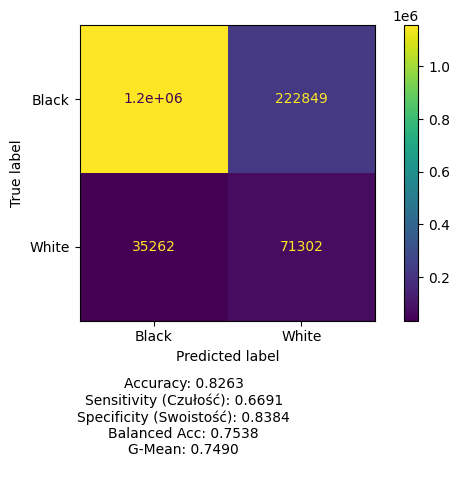

In [21]:
from simple_statistics import create_confusions_matrix
print(root_mean_squared_error(y_test,predictions))
create_confusions_matrix(np.array(y_test),np.array(predictions))

### Funckja to przetwarzania zdjecia:


In [22]:
def look_for_vessels_ml(img,mask,clasifier_,kernel_size):
    mask=mask[:,:,1]
    mask=np.where(mask>0,1,0)
    img=preproces_pipeline(img)
    max_x,max_y=img.shape
    pred_img=np.zeros((max_x, max_y), dtype=np.uint8)

    img=np.pad(img,kernel_size//2,mode="reflect")
    features=[]
    for x in range(max_x):
        for y in range(max_y):
            


_IncompleteInputError: incomplete input (3823874020.py, line 12)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 100}
0.8163453481075503
Training accuracy: 0.9527022526173216
Test accuracy: 0.41964314006060516

In [23]:
print(grid_search.best_params_)
print(grid_search.best_score_)
print('Training accuracy:', grid_search.score(X_train, y_train))
print('Test accuracy:', grid_search.score(X_test, y_test))

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 125}
0.7319588240074142
Training accuracy: 0.7984905894363405
Test accuracy: 0.35586977245616574


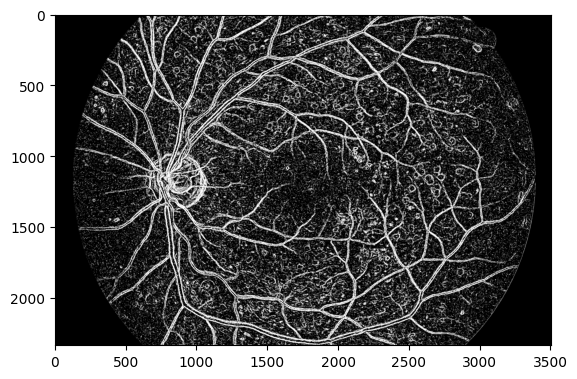

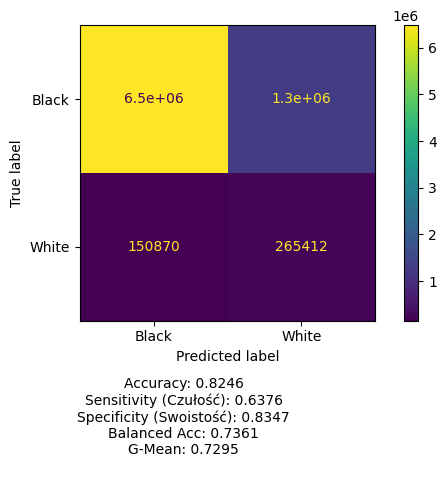

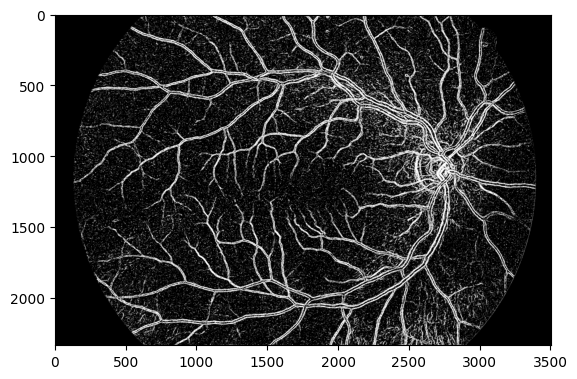

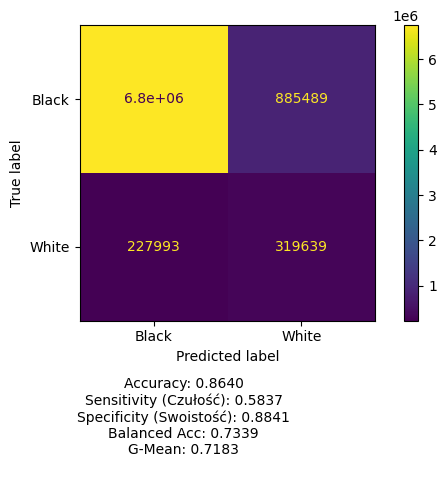

In [24]:
import numpy as np
import cv2

def predict_full_image(
    img,
    mask,
    classifier,
    preprocess_fn,
    kernel_size: int = 5
):
    half = kernel_size // 2

    # preprocessing obrazu
    proc_img = preprocess_fn(img)

    if proc_img.ndim > 2:
        proc_img = cv2.cvtColor(proc_img, cv2.COLOR_RGB2GRAY)

    # maska binarna
    if mask.ndim > 2:
        mask = mask[:, :, 1]
    mask = np.where(mask > 0, 1, 0).astype(np.uint8)

    # padding obrazu
    padded_img = np.pad(proc_img, pad_width=half, mode='reflect')

    height, width = proc_img.shape
    pred_mask = np.zeros((height, width), dtype=np.uint8)

    # tutaj zbieramy dane
    features_list = []
    coords = []

    for x in range(height):
        for y in range(width):

            # jeśli chcesz liczyć tylko w obszarze maski
            if mask[x, y] == 0:
                continue

            patch = padded_img[x:x + kernel_size, y:y + kernel_size]

            if patch.shape[0] != kernel_size or patch.shape[1] != kernel_size:
                continue

            features = extract_features(patch)
            features_list.append(features)
            coords.append((x, y))

    # jedna predykcja dla całego batcha
    features_array = np.asarray(features_list, dtype=np.float32)
    predictions = classifier.predict(features_array)

    # wpisanie predykcji do maski wynikowej
    for (x, y), pred in zip(coords, predictions):
        pred_mask[x, y] = pred
    pred_mask&=mask
    return pred_mask

for idx,element in enumerate(data):
    img=read_img(element[0])
    manual=read_img(element[1])
    mask=read_img(element[2])
    returned_img=predict_full_image(img,mask,grid_search,preproces_pipeline)
    show_img(returned_img)
    manual=manual[:,:,1]
    manual=np.where(manual>0,1,0)
    create_confusions_matrix(manual,returned_img)
    if idx>0:
        break

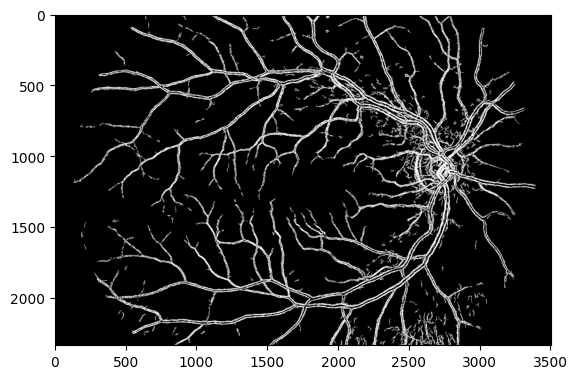

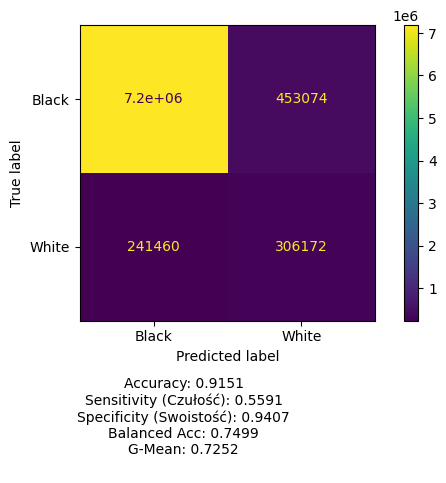

In [27]:
import cv2
import numpy as np

def remove_small_components(mask, min_size=30):

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask.astype(np.uint8),
        connectivity=8
    )

    cleaned = np.zeros_like(mask)

    for i in range(1, num_labels):

        area = stats[i, cv2.CC_STAT_AREA]

        if area >= min_size:
            cleaned[labels == i] = 1

    return cleaned
cleaned=remove_small_components(returned_img,120)
show_img(cleaned)
create_confusions_matrix(manual,cleaned)